In [ ]:
from google.colab import files
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
uploaded = files.upload()

Saving merged_data.csv to merged_data.csv


In [ ]:
merged = pd.read_csv("merged_data.csv")

In [ ]:
target = 'PercentRemaining2100'

predictors = [
    'PercentBufferRemain'
]

X = merged[predictors]
y = merged[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled = sm.add_constant(X_train_scaled)

model = sm.OLS(y_train, X_train_scaled).fit()

print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     PercentRemaining2100   R-squared:                       0.075
Model:                              OLS   Adj. R-squared:                  0.075
Method:                   Least Squares   F-statistic:                     728.1
Date:                  Tue, 28 Apr 2026   Prob (F-statistic):          2.70e-154
Time:                          01:37:00   Log-Likelihood:                -44134.
No. Observations:                  9024   AIC:                         8.827e+04
Df Residuals:                      9022   BIC:                         8.829e+04
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         38.4445      0.339

In [ ]:
X_test_scaled_const = sm.add_constant(X_test_scaled)

y_pred = model.predict(X_test_scaled_const)

In [ ]:
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("R^2 on test set:", r2)
print("RMSE:", rmse)

R^2 on test set: 0.08155707788603017
RMSE: 31.742625983049678


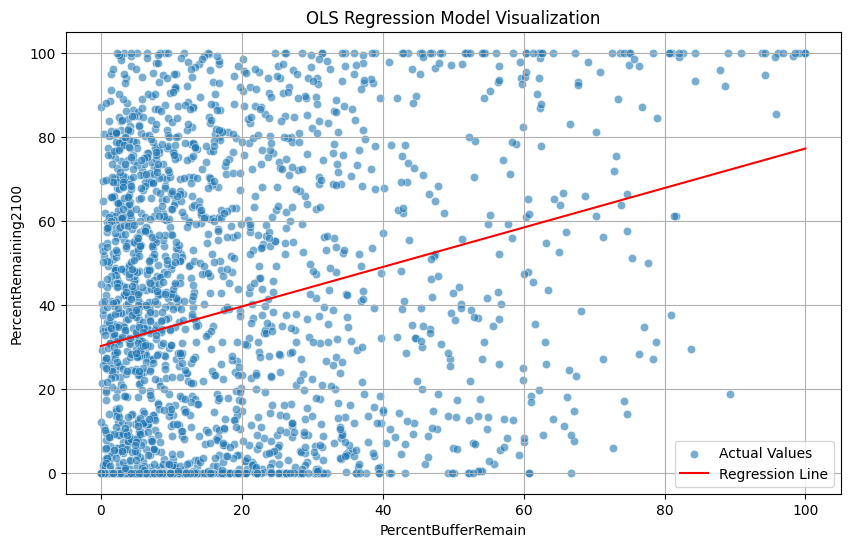

In [ ]:
plot_data = pd.DataFrame({
    'PercentBufferRemain': X_test['PercentBufferRemain'],
    'ActualPercentRemaining2100': y_test,
    'PredictedPercentRemaining2100': y_pred
})

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PercentBufferRemain', y= 'ActualPercentRemaining2100', data=plot_data, alpha= 0.6, label='Actual Values')
sns.lineplot(x='PercentBufferRemain', y='PredictedPercentRemaining2100', data=plot_data.sort_values('PercentBufferRemain'),color='red', label='Regression Line')

plt.title('OLS Regression Model Visualization')
plt.xlabel('PercentBufferRemain')
plt.ylabel('PercentRemaining2100')
plt.legend()
plt.grid(True)
plt.show()